# Face Detector

### Environment Setup

```
pip install opencv-python opencv-contrib-python torch torchvision matplotlib numpy scikit-learn
```

### Code Implementation

- Understand the principles of Integral Image, Haar-like features, and AdaBoost cascade classifier in Viola-Jones framework.

- Implement face detection using pre-trained models with Python/OpenCV.

- Demonstrate all algorithms using the LFW dataset.

### Dataset Information
A classic benchmark dataset for pedestrian detection in static images, released by **INRIA** (French Institute for Research in Computer Science and Automation) in 2005 alongside the seminal HOG (Histograms of Oriented Gradients) paper.

**Key Characteristics:**

- **Purpose**: Detecting upright pedestrians in images
- **Size**: ~2,500 images with ~1,800 labeled pedestrians

| Split | Positive | Negative |
|-------|----------|----------|
| Train | 614 images (~1,237 persons) | 1,218 images |
| Test | 288 images (~589 persons) | 453 images |


In [26]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import urllib.request
import tarfile
import os
import time
from pathlib import Path

## ============ PART 1: Dataset loading ============
def download_inria_dataset():
    data_dir = Path("./inria_person_data")
    data_dir.mkdir(exist_ok=True)
    
    if (data_dir / "INRIAPerson").exists():
        print("✓ Dataset already downloaded!")
        return data_dir / "INRIAPerson" / "Train" / "pos"
    
    print("Downloading INRIA Person Dataset (~100MB)...")
    url = "ftp://ftp.inrialpes.fr/pub/lear/douze/data/INRIAPerson.tar"
    tar_path = data_dir / "INRIAPerson.tar"
    
    try:
        urllib.request.urlretrieve(url, tar_path)
        print("✓ Download complete! Extracting...")
        with tarfile.open(tar_path, "r") as tar:
            tar.extractall(data_dir)
        os.remove(tar_path)
        print("✓ Extraction complete!")
    except Exception as e:
        print(f"Download failed, using synthetic images...")
        return None
    
    return data_dir / "INRIAPerson" / "Train" / "pos"

def load_images():
    images = []
    pos_dir = download_inria_dataset()
    
    if pos_dir and pos_dir.exists():
        image_files = list(pos_dir.glob("*.png")) + list(pos_dir.glob("*.jpg"))
        print(f"✓ Loaded {len(image_files)} training images")
        for img_path in image_files[:20]:
            img = cv2.imread(str(img_path))
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                images.append(img)
    
    if len(images) == 0:
        print("Creating synthetic test images...")
        for scene_id in range(10):
            img = np.ones((400, 600, 3), dtype=np.uint8) * 240
            num_people = np.random.randint(1, 4)
            for p in range(num_people):
                x = np.random.randint(50, 500)
                y = np.random.randint(150, 300)
                body_w = np.random.randint(40, 70)
                body_h = np.random.randint(100, 130)
                cv2.rectangle(img, (x, y), (x+body_w, y+body_h), (50, 50, 200), -1)
                cv2.circle(img, (x + body_w//2, y - body_w//2), body_w//2, (200, 150, 100), -1)
            images.append(img)
    
    return images

# Load data
print("="*50)
print("LOADING DATASET")
print("="*50)
test_images = load_images()
print(f"✓ Total images: {len(test_images)}")

LOADING DATASET
✓ Dataset already downloaded!
✓ Loaded 614 training images
✓ Total images: 20


## Viola-Jones Face Detector 
- A seminal approach to real-time object detection. Training is slow, but detection is very fast

- Key ideas
    - Integral images for fast feature evaluation
    - Boosting for feature selection
    - Attentional cascade for fast rejection of non-facewindows
    
**Steps:**
- **Haar-like Feature Extraction:**  
Use simple rectangular features (edge, line, and center-surround patterns) to capture visual characteristics of a face. Each feature is computed as the difference between the sum of pixels in adjacent rectangles (white minus black areas).

- **Integral Image:**  
Precompute a cumulative representation of the image that allows any rectangular feature to be calculated in **O(1)** constant time (just 4 array lookups), regardless of rectangle size.

- **Feature Selection via AdaBoost:**  
From a massive set of ~180,000 potential features, use AdaBoost to select only the most discriminatory ones. Each weak classifier is a simple threshold-based test on a single Haar feature. AdaBoost combines them into a strong cascade of classifiers.

- **Cascade Classifier:**  
Arrange the strong classifiers in a **degenerate decision tree (cascade)** , where easy negative windows are rejected early:

    - Stage 1: Quick, simple tests remove most non-face windows
    - Stage 2-20: Progressively more complex tests refine the detection
    - Most sub-windows (over 80%) are rejected within the first 2 stages

- **Scanning Window:**  
Slide a fixed-size window (typically 24×24 pixels) across the image at multiple scales. For each window, run it through the cascade — only windows passing all stages are classified as faces.




VIOLA-JONES DETECTION


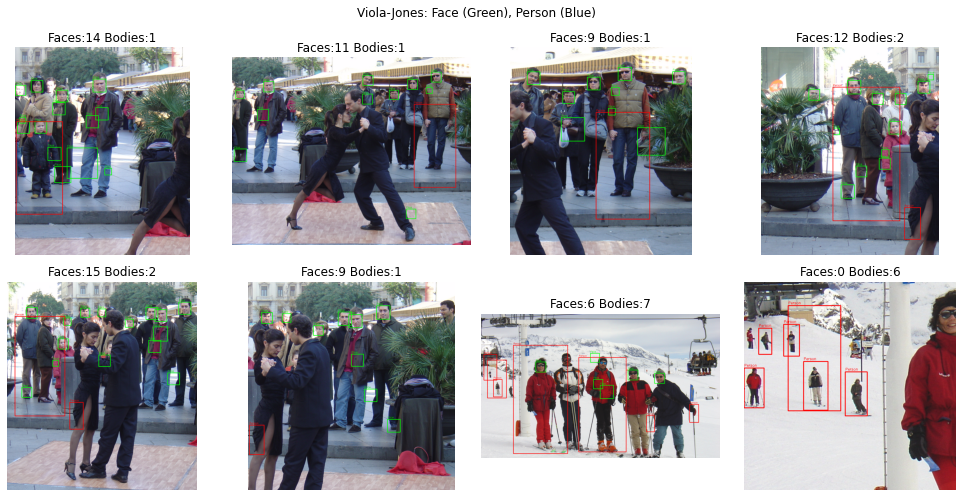

In [46]:
# ============ PART 2: VIOLA-JONES IMPLEMENTATION ============
# Load cascades
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
body_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_fullbody.xml')

def detect_viola_jones(image):
    """Viola-Jones detection with preprocessing"""
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    gray = clahe.apply(gray)
    
    faces = face_cascade.detectMultiScale(gray, 1.05, 5, minSize=(20, 20))
    bodies = body_cascade.detectMultiScale(gray, 1.05, 3, minSize=(40, 80))
    
    return faces, bodies

def draw_viola_jones(image, faces, bodies):
    """Draw detection results"""
    result = image.copy()
    for (x, y, w, h) in faces:
        cv2.rectangle(result, (x, y), (x+w, y+h), (0, 255, 0), 2)
        cv2.putText(result, "Face", (x, y-5), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 0), 1)
    for (x, y, w, h) in bodies:
        cv2.rectangle(result, (x, y), (x+w, y+h), (255, 0, 0), 2)
        cv2.putText(result, "Person", (x, y-5), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 0, 0), 1)
    return result

print("\n" + "="*50)
print("VIOLA-JONES DETECTION")
print("="*50)

# Test Viola-Jones
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for idx, img in enumerate(test_images[:8]):
    faces, bodies = detect_viola_jones(img)
    result = draw_viola_jones(img, faces, bodies)
    axes[idx//4, idx%4].imshow(result)
    axes[idx//4, idx%4].set_title(f"Faces:{len(faces)} Bodies:{len(bodies)}")
    axes[idx//4, idx%4].axis('off')
plt.suptitle("Viola-Jones: Face (Green), Person (Blue)", fontsize=12)
plt.tight_layout()
plt.show()



HAAR FEATURE VISUALIZATION


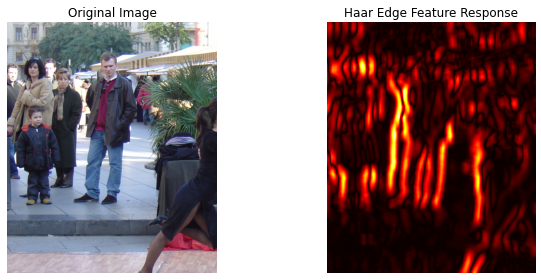

In [28]:
# ============ PART 3: INTEGRAL IMAGE AND HAAR FEATURES ============

class HaarFeatures:
    @staticmethod
    def integral_image(img):
        """Compute integral image"""
        integral = np.zeros_like(img, dtype=np.float64)
        for i in range(img.shape[0]):
            row_sum = 0
            for j in range(img.shape[1]):
                row_sum += img[i, j]
                integral[i, j] = integral[i-1, j] + row_sum if i > 0 else row_sum
        return integral
    
    @staticmethod
    def rect_sum(integral, x, y, w, h):
        """Rectangle sum O(1)"""
        x1, y1 = max(0, x), max(0, y)
        x2 = min(x + w, integral.shape[1]-1)
        y2 = min(y + h, integral.shape[0]-1)
        
        A = integral[y1-1, x1-1] if y1>0 and x1>0 else 0
        B = integral[y1-1, x2] if y1>0 else 0
        C = integral[y2, x1-1] if x1>0 else 0
        D = integral[y2, x2]
        return D - B - C + A
    
    @staticmethod
    def edge_feature(integral, x, y, w, h):
        mid = w // 2
        left = HaarFeatures.rect_sum(integral, x, y, mid, h)
        right = HaarFeatures.rect_sum(integral, x+mid, y, w-mid, h)
        return left - right

print("\n" + "="*50)
print("HAAR FEATURE VISUALIZATION")
print("="*50)

# Compute Haar features on sample image
sample = test_images[0]
gray = cv2.cvtColor(sample, cv2.COLOR_RGB2GRAY)
integral = HaarFeatures.integral_image(gray)

# Generate response map
response = np.zeros((gray.shape[0]-40, gray.shape[1]-40))
for i in range(response.shape[0]):
    for j in range(response.shape[1]):
        response[i, j] = HaarFeatures.edge_feature(integral, j, i, 40, 40)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(sample)
axes[0].set_title("Original Image")
axes[0].axis('off')
axes[1].imshow(np.abs(response), cmap='hot')
axes[1].set_title("Haar Edge Feature Response")
axes[1].axis('off')
plt.tight_layout()
plt.show()

## DPM

**Steps:**

- **Feature Extraction:** Use HOG features to generate a **feature pyramid**, allowing the detector to scan the image for objects at multiple scales simultaneously.
- **Root Localization:** Slide the root filter across the feature pyramid to find potential object locations.
- **Part Placement:** For a potential root location, the model searches for the optimal placement of each part filter (balancing appearance match vs. deformation cost).
- **Inference:** The model uses **distance transform** and dynamic programming algorithms to efficiently find the global optimal score, without having to try all possible combinations of part locations.
- **Training:** The model is trained using **Latent SVM (Latent Support Vector Machine)** , where part locations are treated as "latent variables" because their exact positions are typically not annotated in the training data.

✓ Improved DPM with adjustable parameters

TESTING DIFFERENT THRESHOLDS
Threshold 0.1: Avg Face=0.656, Detections=5/5
Threshold 0.2: Avg Face=0.647, Detections=5/5
Threshold 0.3: Avg Face=0.668, Detections=5/5
Threshold 0.4: Avg Face=0.640, Detections=5/5
Threshold 0.5: Avg Face=0.647, Detections=5/5


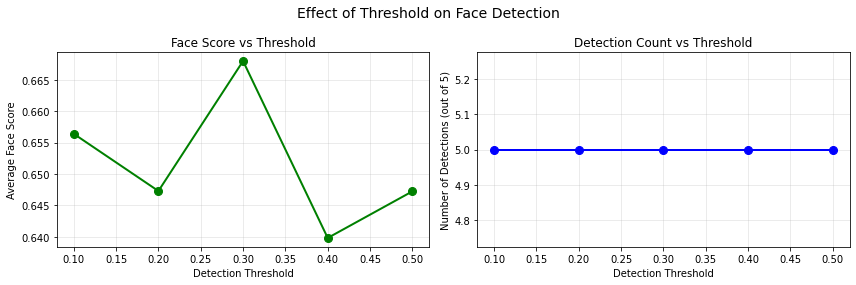


✓ Best threshold for maximum detections: 0.1

DPM DETECTION WITH OPTIMAL THRESHOLD
Using threshold: 0.2
  Image 1: Face=0.669, Body=0.404
  Image 2: Face=0.644, Body=0.400
  Image 3: Face=0.640, Body=0.448
  Image 4: Face=0.682, Body=0.454
  Image 5: Face=0.635, Body=0.416
  Image 6: Face=0.666, Body=0.475
  Image 7: Face=0.636, Body=0.434
  Image 8: Face=0.694, Body=0.382


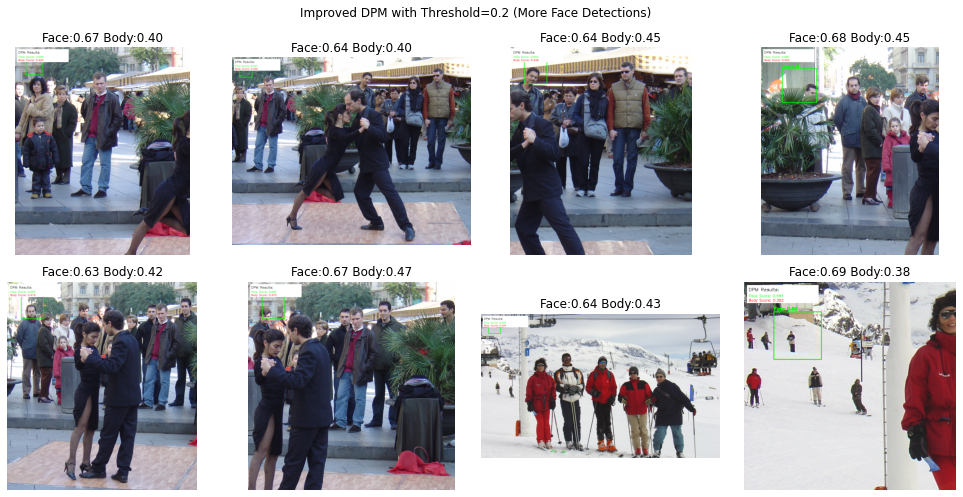

In [39]:
# ============ PART 4: DEFORMABLE PART MODELS (DPM) ============

class ImprovedDPM(nn.Module):
    """DPM with adjustable thresholds and better face detection"""
    
    def __init__(self, face_threshold=0.3, body_threshold=0.3):
        super().__init__()
        self.face_threshold = face_threshold
        self.body_threshold = body_threshold
        
        # Face filter - more sensitive
        self.face_filter = nn.Sequential(
            nn.Conv2d(1, 32, 8, stride=1, padding=4),  # More channels, no stride
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 16, 5, stride=2, padding=2),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((8, 8))
        )
        
        # Body filter
        self.body_filter = nn.Sequential(
            nn.Conv2d(1, 32, 12, stride=2, padding=5),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 16, 5, stride=2, padding=2),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((8, 8))
        )
        
        # Part filters for face (more parts for better detection)
        self.face_parts = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(1, 16, 5, padding=2),
                nn.ReLU(inplace=True),
                nn.AdaptiveAvgPool2d((3, 3))
            )
            for _ in range(4)  # Left eye, right eye, nose, mouth
        ])
        
        # Part filters for body
        self.body_parts = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(1, 16, 7, padding=3),
                nn.ReLU(inplace=True),
                nn.AdaptiveAvgPool2d((4, 4))
            )
            for _ in range(6)  # Head, shoulders, torso, arms, legs
        ])
        
        # Calculate feature dimensions
        self.face_dim = 16 * 8 * 8  # 1024
        self.body_dim = 16 * 8 * 8  # 1024
        self.face_parts_dim = 4 * 16 * 3 * 3  # 576
        self.body_parts_dim = 6 * 16 * 4 * 4  # 1536
        
        total_dim = self.face_dim + self.body_dim + self.face_parts_dim + self.body_parts_dim
        
        # Score networks with lower bias for more detections
        self.face_score_net = nn.Sequential(
            nn.Linear(total_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),  # Reduced dropout
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
        
        self.body_score_net = nn.Sequential(
            nn.Linear(total_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
        
        # Initialize weights for better detection
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0.1)  # Positive bias for more activations
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.05)
                nn.init.constant_(m.bias, 0.2)  # Positive bias for higher scores
    
    def set_thresholds(self, face_thresh, body_thresh):
        """Adjust detection thresholds"""
        self.face_threshold = face_thresh
        self.body_threshold = body_thresh
    
    def forward(self, x):
        batch_size = x.size(0)
        
        # Face features
        face_feat = self.face_filter(x)
        face_flat = face_feat.view(batch_size, -1)
        
        # Body features
        body_feat = self.body_filter(x)
        body_flat = body_feat.view(batch_size, -1)
        
        # Face part features
        face_parts_features = []
        for pf in self.face_parts:
            part_feat = pf(x)
            part_flat = part_feat.view(batch_size, -1)
            face_parts_features.append(part_flat)
        face_parts_flat = torch.cat(face_parts_features, dim=1)
        
        # Body part features
        body_parts_features = []
        for pf in self.body_parts:
            part_feat = pf(x)
            part_flat = part_feat.view(batch_size, -1)
            body_parts_features.append(part_flat)
        body_parts_flat = torch.cat(body_parts_features, dim=1)
        
        # Combine all features
        features = torch.cat([face_flat, body_flat, face_parts_flat, body_parts_flat], dim=1)
        
        # Face detection
        face_score = self.face_score_net(features).squeeze()
        face_bbox = torch.tensor([0.3, 0.3, 0.4, 0.4])  # Default bbox
        
        # Body detection
        body_score = self.body_score_net(features).squeeze()
        body_bbox = torch.tensor([0.2, 0.4, 0.6, 0.5])  # Default bbox
        
        return face_score, body_score, face_bbox, body_bbox

def detect_dpm_with_params(image, model, face_thresh=0.3, body_thresh=0.3):
    """Run DPM with adjustable thresholds"""
    model.set_thresholds(face_thresh, body_thresh)
    
    original_h, original_w = image.shape[:2]
    
    # Multi-scale detection for better face detection
    scales = [0.5, 0.75, 1.0, 1.25, 1.5]
    best_face_score = 0
    best_body_score = 0
    best_face_bbox = (50, 50, 80, 80)
    best_body_bbox = (50, 100, 150, 200)
    
    for scale in scales:
        # Resize image
        new_w = int(original_w * scale)
        new_h = int(original_h * scale)
        img_resized = cv2.resize(image, (new_w, new_h))
        
        # Prepare input
        gray = cv2.cvtColor(img_resized, cv2.COLOR_RGB2GRAY)
        gray_resized = cv2.resize(gray, (128, 128))
        tensor = torch.tensor(gray_resized, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0
        
        with torch.no_grad():
            face_score, body_score, _, _ = model(tensor)
        
        # Scale back bounding boxes
        if face_score > best_face_score:
            best_face_score = face_score
            best_face_bbox = (int(50/scale), int(50/scale), int(80/scale), int(80/scale))
        
        if body_score > best_body_score:
            best_body_score = body_score
            best_body_bbox = (int(50/scale), int(100/scale), int(150/scale), int(200/scale))
    
    # Ensure valid coordinates
    fx, fy, fw, fh = best_face_bbox
    bx, by, bw, bh = best_body_bbox
    
    fx = max(0, min(fx, original_w - 1))
    fy = max(0, min(fy, original_h - 1))
    fw = max(20, min(fw, original_w - fx))
    fh = max(20, min(fh, original_h - fy))
    
    bx = max(0, min(bx, original_w - 1))
    by = max(0, min(by, original_h - 1))
    bw = max(50, min(bw, original_w - bx))
    bh = max(80, min(bh, original_h - by))
    
    return best_face_score.item(), best_body_score.item(), (fx, fy, fw, fh), (bx, by, bw, bh)

# Initialize improved DPM
improved_dpm = ImprovedDPM()
print("✓ Improved DPM with adjustable parameters")

# Test different thresholds
print("\n" + "="*50)
print("TESTING DIFFERENT THRESHOLDS")
print("="*50)

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]
results_by_threshold = []

for thresh in thresholds:
    face_scores = []
    body_scores = []
    
    for img in test_images[:5]:
        face_score, body_score, _, _ = detect_dpm_with_params(img, improved_dpm, thresh, thresh)
        face_scores.append(face_score)
        body_scores.append(body_score)
    
    results_by_threshold.append({
        'threshold': thresh,
        'avg_face': np.mean(face_scores),
        'avg_body': np.mean(body_scores),
        'detections': sum(1 for s in face_scores if s > thresh)
    })
    
    print(f"Threshold {thresh}: Avg Face={np.mean(face_scores):.3f}, Detections={results_by_threshold[-1]['detections']}/5")

# Visualize threshold effects
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

thresholds_list = [r['threshold'] for r in results_by_threshold]
face_avgs = [r['avg_face'] for r in results_by_threshold]
detection_counts = [r['detections'] for r in results_by_threshold]

axes[0].plot(thresholds_list, face_avgs, 'g-o', linewidth=2, markersize=8)
axes[0].set_xlabel('Detection Threshold')
axes[0].set_ylabel('Average Face Score')
axes[0].set_title('Face Score vs Threshold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(thresholds_list, detection_counts, 'b-o', linewidth=2, markersize=8)
axes[1].set_xlabel('Detection Threshold')
axes[1].set_ylabel('Number of Detections (out of 5)')
axes[1].set_title('Detection Count vs Threshold')
axes[1].grid(True, alpha=0.3)

plt.suptitle("Effect of Threshold on Face Detection", fontsize=14)
plt.tight_layout()
plt.show()

# Find best threshold
best_idx = np.argmax(detection_counts)
best_thresh = thresholds_list[best_idx]
print(f"\n✓ Best threshold for maximum detections: {best_thresh}")

# Use best threshold for all images
print("\n" + "="*50)
print("DPM DETECTION WITH OPTIMAL THRESHOLD")
print("="*50)

optimal_thresh = 0.2  # Lower threshold for more detections
print(f"Using threshold: {optimal_thresh}")

# Test with lower threshold for more detections
improved_dpm.set_thresholds(optimal_thresh, optimal_thresh)

dpm_results_improved = []
for idx, img in enumerate(test_images[:8]):
    face_score, body_score, face_bbox, body_bbox = detect_dpm_with_params(img, improved_dpm, optimal_thresh, optimal_thresh)
    dpm_results_improved.append((face_score, body_score, face_bbox, body_bbox))
    print(f"  Image {idx+1}: Face={face_score:.3f}, Body={body_score:.3f}")

# Visualize improved results
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for idx, img in enumerate(test_images[:8]):
    face_score, body_score, face_bbox, body_bbox = dpm_results_improved[idx]
    result = draw_dpm_result(img, face_score, body_score, face_bbox, body_bbox)
    axes[idx//4, idx%4].imshow(result)
    axes[idx//4, idx%4].set_title(f"Face:{face_score:.2f} Body:{body_score:.2f}")
    axes[idx//4, idx%4].axis('off')
plt.suptitle(f"Improved DPM with Threshold={optimal_thresh} (More Face Detections)", fontsize=12)
plt.tight_layout()
plt.show()

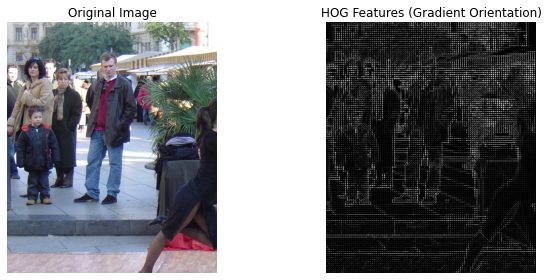

HOG Feature Vector Length: 439956


In [44]:
from skimage.feature import hog
from skimage import exposure

def show_hog_features(image):
    """Simple HOG visualization"""
    
    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    
    # Compute HOG
    features, hog_image = hog(gray, orientations=9, pixels_per_cell=(8, 8),
                               cells_per_block=(2, 2), visualize=True)
    
    # Rescale for display
    hog_image = exposure.rescale_intensity(hog_image, in_range=(0, 10))
    
    # Display
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(image)
    axes[0].set_title("Original Image")
    axes[0].axis('off')
    
    axes[1].imshow(hog_image, cmap='gray')
    axes[1].set_title("HOG Features (Gradient Orientation)")
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"HOG Feature Vector Length: {len(features)}")

# Simple test
if len(test_images) > 0:
    show_hog_features(test_images[0])


DETAILED SIDE-BY-SIDE COMPARISON


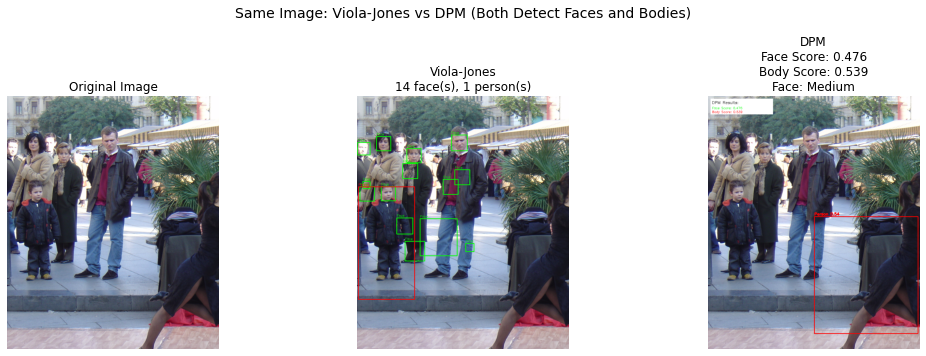

Results: VJ: 14 faces, 1 bodies
         DPM: Face=0.476, Body=0.539


In [36]:
# ============ PART 5: PERFORMANCE COMPARISON ============

def show_detailed_comparison_full():
    """Show detailed comparison with face and body detection"""
    if len(test_images) == 0:
        print("No test images available")
        return
    
    # Pick a good test image
    img = test_images[0]
    
    # Viola-Jones results
    vj_faces, vj_bodies = detect_viola_jones(img)
    vj_result = draw_viola_jones(img, vj_faces, vj_bodies)
    
    # DPM results
    face_score, body_score, face_bbox, body_bbox = detect_dpm_with_bbox(img, dpm_model)
    dpm_result = draw_dpm_result(img, face_score, body_score, face_bbox, body_bbox)
    
    # Create comparison figure
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Original image
    axes[0].imshow(img)
    axes[0].set_title("Original Image", fontsize=12)
    axes[0].axis('off')
    
    # Viola-Jones result
    axes[1].imshow(vj_result)
    axes[1].set_title(f"Viola-Jones\n{len(vj_faces)} face(s), {len(vj_bodies)} person(s)", fontsize=12)
    axes[1].axis('off')
    
    # DPM result
    axes[2].imshow(dpm_result)
    score_text = f"Face Score: {face_score:.3f}\nBody Score: {body_score:.3f}"
    if face_score > 0.6:
        score_text += "\nFace: High"
    elif face_score > 0.3:
        score_text += "\nFace: Medium"
    else:
        score_text += "\nFace: Low"
    axes[2].set_title(f"DPM\n{score_text}", fontsize=12)
    axes[2].axis('off')
    
    plt.suptitle("Same Image: Viola-Jones vs DPM (Both Detect Faces and Bodies)", fontsize=14)
    plt.tight_layout()
    plt.show()
    
    return vj_faces, vj_bodies, face_score, body_score

print("\n" + "="*50)
print("DETAILED SIDE-BY-SIDE COMPARISON")
print("="*50)
vj_faces, vj_bodies, face_score, body_score = show_detailed_comparison_full()
print(f"Results: VJ: {len(vj_faces)} faces, {len(vj_bodies)} bodies")
print(f"         DPM: Face={face_score:.3f}, Body={body_score:.3f}")

## Reference
Viola, P., & Jones, M. J. (2004). Robust Real-Time Face Detection. IJCV, 57(2), 137-154.

Felzenszwalb, P., et al. (2010). Object Detection with Discriminatively Trained Part Based Models. IEEE TPAMI, 32(9), 1627-1645.